In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

In [16]:
import os

# 1. Move Jupyter's working directory into the script folder
%cd ~/GraphFEX/HR/scripts
%cd ~/blue/chunmei.wang/hudsonshields/GraphFEX/HR/scripts


mean_times = []
std_dev_times = []

controller_epochs = 5
for num_workers in range(1, 11):
    # 2. Run the script directly without the folder prefix
    t1 = %timeit -o -r5 -n1 !python HR/scripts/eval_controller_dim_x.py --num_workers {num_workers} --num_epochs 80 --controller_epochs {controller_epochs}

    # scale by number of controller epochs because each timing run includes multiple controller epochs, and i want to find the per epoch time
    mean_times.append(t1.average / controller_epochs)
    std_dev_times.append(t1.stdev / controller_epochs)

# 3. Optional: Move back to your project root when finished
%cd ~/GraphFEX
%cd ~/blue/chunmei.wang/hudsonshields/GraphFEX

[Errno 2] No such file or directory: '/home/hudsonshields/GraphFEX/HR/scripts'
/blue/chunmei.wang/hudsonshields/GraphFEX
[Errno 2] No such file or directory: '/home/hudsonshields/blue/chunmei.wang/hudsonshields/GraphFEX/HR/scripts'
/blue/chunmei.wang/hudsonshields/GraphFEX


Using device: cuda
Detected SLURM environment with 10 CPUs allocated for this task
Using 1 parallel processes for candidate evaluation.
Using device: cuda
Evaluating candidate 0 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluating candidate 2 on GPU 0
Evaluating candidate 3 on GPU 0
Evaluating candidate 4 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.04 seconds
Epoch 0 pmfs: [array([[0.30298173, 0.35095802, 0.34606028]], dtype=float32), array([[0.32014284, 0.35927838, 0.32057878]], dtype=float32), array([[0.3007222 , 0.35347658, 0.34580117]], dtype=float32), array([[0.13234966, 0.12487228, 0.16365236, 0.14688033, 0.14956826,
        0.12997837, 0.15269881]], dtype=float32), array([[0.13819052, 0.16535595, 0.13160427, 0.13962367, 0.14775671,
        0.13147244, 0.14599638]], dtype=float32), array([[0.15210946, 0.12929729, 0.13359621, 

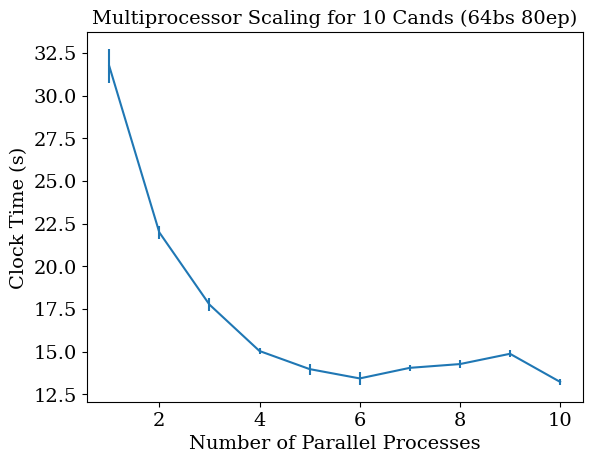

In [17]:
plt.errorbar(range(1, 11), mean_times, yerr=std_dev_times)
plt.xlabel(r"Number of Parallel Processes")
plt.ylabel(r"Clock Time (s)")
plt.title(r"Multiprocessor Scaling for 10 Cands (64bs 80ep)")
plt.show()

In [ ]:
%cd ~/GraphFEX/HR/scripts
%cd ~/blue/chunmei.wang/hudsonshields/GraphFEX/HR/scripts

controller_epochs = 5
cands_per_epoch = 2

small_num_nodes = [20, 50, 500]
order_of_mag_nodes = [10, 100, 1000, 10000]
node_counts = sorted(set(small_num_nodes + order_of_mag_nodes))

timing_results = {}

pct_edges = 1.0
for n in node_counts:
    degree = max(1, int(pct_edges * n))

    # K = 0.5d = 0.05n, giving approximately 20 nodes per batch.
    desired_batches = max(1, int(0.1 * degree))

    t1 = %timeit -o -r5 -n1 !python HR/scripts/eval_controller_dim_x.py \
        --num_workers 1 \
        --num_epochs 60 \
        --controller_epochs {controller_epochs} \
        --nodes {n} \
        --num_cands_per_epoch {cands_per_epoch} \
        --num_stoch_batches {desired_batches} \
        --pct_edges {pct_edges}

    timing_results[n] = {
        "mean": t1.average / controller_epochs / cands_per_epoch,
        "std": t1.stdev / controller_epochs / cands_per_epoch,
    }

%cd ~/GraphFEX
%cd /blue/chunmei.wang/hudsonshields/GraphFEX

[Errno 2] No such file or directory: '/home/hudsonshields/GraphFEX/HR/scripts'
/blue/chunmei.wang/hudsonshields/GraphFEX
[Errno 2] No such file or directory: '/home/hudsonshields/blue/chunmei.wang/hudsonshields/GraphFEX/HR/scripts'
/blue/chunmei.wang/hudsonshields/GraphFEX


Using device: cuda
Detected SLURM environment with 1 CPUs allocated for this task
Using 1 parallel processes for candidate evaluation.
Using device: cuda
Evaluating candidate 0 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluation time for fex epoch: 0.07 seconds
Epoch 0 pmfs: [array([[0.36028597, 0.31176743, 0.3279466 ]], dtype=float32), array([[0.3609234 , 0.31554487, 0.32353166]], dtype=float32), array([[0.33160508, 0.3941712 , 0.27422372]], dtype=float32), array([[0.13404845, 0.13406453, 0.15932645, 0.14537433, 0.14734879,
        0.14364427, 0.13619316]], dtype=float32), array([[0.16155946, 0.1478529 , 0.12678409, 0.14467181, 0.14257222,
        0.14054994, 0.13600954]], dtype=float32), array([[0.14682388, 0.14479068, 0.14612658, 0.15361485, 0.14775667,
        0.13123745, 0.12964988]], dtype=float32), array([[0.14818107, 0.1409699 , 0.13993183, 0.17465363, 0.13817048,
        0.12864704, 0.12944607]], dtype=float32), array([[0.36332604, 0.3199307 , 0.31674325]], dtype=float32), arr

In [2]:
%cd ~/GraphFEX/HR/scripts
%cd ~/blue/chunmei.wang/hudsonshields/GraphFEX/HR/scripts


control_timing_results = {}

for n in node_counts:
    t1 = %timeit -o -r5 -n1 !python HR/scripts/eval_controller_dim_x.py \
        --num_workers 1 \
        --num_epochs 60 \
        --controller_epochs {controller_epochs} \
        --nodes {n} \
        --num_cands_per_epoch {cands_per_epoch} \
        --pct_edges 1.0

    control_timing_results[n] = {
        "mean": t1.average / controller_epochs / cands_per_epoch,
        "std": t1.stdev / controller_epochs / cands_per_epoch,
    }

%cd ~/GraphFEX
%cd /blue/chunmei.wang/hudsonshields/GraphFEX

[Errno 2] No such file or directory: '/home/hudsonshields/GraphFEX/HR/scripts'
/blue/chunmei.wang/hudsonshields/GraphFEX
[Errno 2] No such file or directory: '/home/hudsonshields/blue/chunmei.wang/hudsonshields/GraphFEX/HR/scripts'
/blue/chunmei.wang/hudsonshields/GraphFEX


Using device: cuda
Detected SLURM environment with 1 CPUs allocated for this task
Using 1 parallel processes for candidate evaluation.
Using device: cuda
Evaluating candidate 0 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluation time for fex epoch: 0.07 seconds
Epoch 0 pmfs: [array([[0.36028597, 0.31176743, 0.3279466 ]], dtype=float32), array([[0.3609234 , 0.31554487, 0.32353166]], dtype=float32), array([[0.33160508, 0.3941712 , 0.27422372]], dtype=float32), array([[0.13404845, 0.13406453, 0.15932645, 0.14537433, 0.14734879,
        0.14364427, 0.13619316]], dtype=float32), array([[0.16155946, 0.1478529 , 0.12678409, 0.14467181, 0.14257222,
        0.14054994, 0.13600954]], dtype=float32), array([[0.14682388, 0.14479068, 0.14612658, 0.15361485, 0.14775667,
        0.13123745, 0.12964988]], dtype=float32), array([[0.14818107, 0.1409699 , 0.13993183, 0.17465363, 0.13817048,
        0.12864704, 0.12944607]], dtype=float32), array([[0.36332604, 0.3199307 , 0.31674325]], dtype=float32), arr

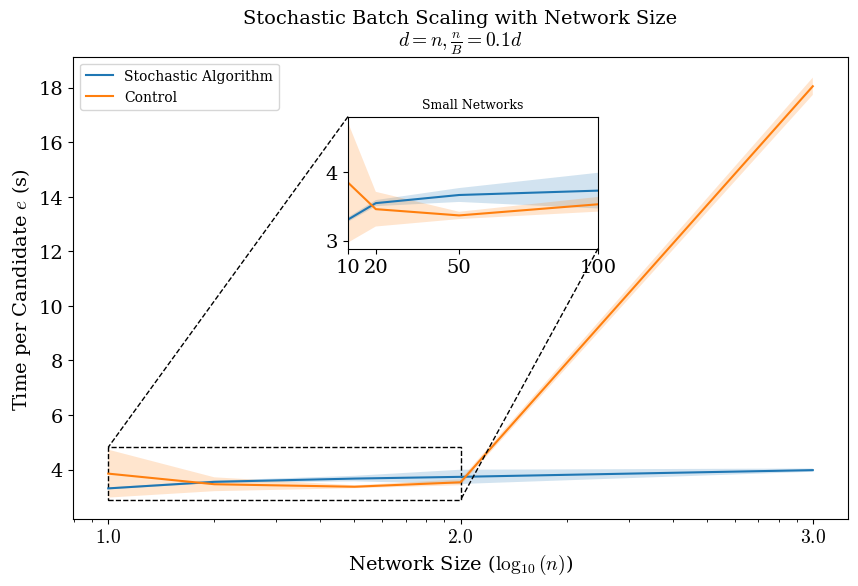

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

main_nodes = node_counts[:-1]
main_means = [timing_results[n]["mean"] for n in main_nodes]
main_stds = [timing_results[n]["std"] for n in main_nodes]

fig, ax_main = plt.subplots(figsize=(10, 6))


ax_main.plot(main_nodes, main_means, label=r"Stochastic Algorithm")
ax_main.fill_between(
    main_nodes,
    np.array(main_means) - np.array(main_stds),
    np.array(main_means) + np.array(main_stds),
    alpha=0.2
)

control_main_means = [control_timing_results[n]["mean"] for n in main_nodes]
control_main_stds = [control_timing_results[n]["std"] for n in main_nodes]
ax_main.plot(
    main_nodes,
    control_main_means,
    label=r"Control"
)
ax_main.fill_between(
    main_nodes,
    np.array(control_main_means) - np.array(control_main_stds),
    np.array(control_main_means) + np.array(control_main_stds),
    alpha=0.2
)
ax_main.legend(fontsize=10)

# Equally spaces 10, 100, and 1000 along the horizontal axis.
ax_main.set_xscale("log")
ax_main.set_xticks(order_of_mag_nodes[:-1])
ax_main.set_xticklabels(
    [fr"${np.log10(n)}$" for n in order_of_mag_nodes[:-1]] # add 10 to the tick labels
)

ax_main.set_xlabel(r"Network Size ($\log_{10}(n)$)")
ax_main.set_ylabel(r"Time per Candidate $e$ (s) ")
ax_main.set_title(
    r"Stochastic Batch Scaling with Network Size"
    "\n"
    r"$d=n, \frac{n}{B}=0.1d$"
)

# Linear-scale inset for the small networks.
zoom_nodes = [10, 20, 50, 100]
zoom_means = [timing_results[n]["mean"] for n in zoom_nodes]
zoom_stds = [timing_results[n]["std"] for n in zoom_nodes]
zoom_control_means = [control_timing_results[n]["mean"] for n in zoom_nodes]
zoom_control_stds = [control_timing_results[n]["std"] for n in zoom_nodes]

ax_zoom = fig.add_axes([0.40, 0.56, 0.25, 0.22])

ax_zoom.plot(zoom_nodes, zoom_means)
ax_zoom.fill_between(
    zoom_nodes,
    np.array(zoom_means) - np.array(zoom_stds),
    np.array(zoom_means) + np.array(zoom_stds),
    alpha=0.2
)
ax_zoom.plot(zoom_nodes, zoom_control_means)
ax_zoom.fill_between(
    zoom_nodes,
    np.array(zoom_control_means) - np.array(zoom_control_stds),
    np.array(zoom_control_means) + np.array(zoom_control_stds),
    alpha=0.2
)

ax_zoom.set_xticks(zoom_nodes)
ax_zoom.set_xticklabels([str(n) for n in zoom_nodes])
ax_zoom.set_title(r"Small Networks", fontsize=9)
ax_zoom.set_xlabel("")
ax_zoom.set_ylabel("")

ax_zoom.set_xlim(10, 100)

mark_inset(ax_main, ax_zoom, loc1=2, loc2=4, fc="none", ec="black", linestyle="--")

plt.show()